In [ ]:
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install -y ./google-chrome-stable_current_amd64.deb -q
!wget -q -O - https://dl.google.com/linux/linux_signing_key.pub | apt-key add -
!apt-get update -q
!apt-get install -y google-chrome-stable -q
!pip install selenium webdriver-manager selenium_stealth -q

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium_stealth import stealth
import time
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import re

In [5]:
class SeleniumParser:
  @classmethod
  def start_work(cls):
    options = Options()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--window-size=1920,1080")

    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

    stealth(driver, languages=["ru-RU", "ru"], vendor="Google Inc.", platform="Win32",
            webgl_vendor="Intel Inc.", renderer="Intel Iris OpenGL Engine", fix_hairline=True)

    return driver

* `1–9` = внутри МКАД;
* `10` = около МКАД / почти граница;
* `11+` = за МКАД: дальние МЦД всякие

In [43]:
METRO_DICT = {
    'Авиамоторная': 4,
    'Автозаводская': 4,
    'Академическая': 5,
    'Александровский сад': 1,
    'Алексеевская': 5,
    'Алма-Атинская': 8,
    'Алтуфьево': 10,
    'Аминьевская': 6,
    'Андроновка': 5,
    'Аникеевка': 16,
    'Аннино': 10,
    'Апрелевка': 18,
    'Арбатская': 1,
    'Аэропорт': 5,
    'Бабушкинская': 7,
    'Багратионовская': 5,
    'Баковка': 13,
    'Балтийская': 5,
    'Баррикадная': 2,
    'Бауманская': 3,
    'Беговая': 3,
    'Белокаменная': 6,
    'Беломорская': 10,
    'Белорусская': 2,
    'Беляево': 7,
    'Бескудниково': 6,
    'Бибирево': 8,
    'Библиотека имени Ленина': 1,
    'Битца': 10,
    'Битцевский парк': 10,
    'Борисово': 7,
    'Боровицкая': 1,
    'Боровское шоссе': 10,
    'Ботанический сад': 5,
    'Братиславская': 7,
    'Бульвар Адмирала Ушакова': 11,
    'Бульвар Дмитрия Донского': 10,
    'Бульвар Рокоссовского': 7,
    'Бунинская аллея': 11,
    'Бутово': 10,
    'Бутырская': 5,
    'Быково': 17,
    'Варшавская': 6,
    'ВДНХ': 6,
    'Верхние Котлы': 5,
    'Верхние Лихоборы': 7,
    'Вешняки': 7,
    'Владыкино': 5,
    'Внуково': 11,
    'Водники': 13,
    'Водный стадион': 7,
    'Войковская': 6,
    'Волгоградский проспект': 4,
    'Волжская': 6,
    'Волоколамская': 6,
    'Воробьевы горы': 4,
    'Воробьёвы горы': 4,
    'Воронцовская': 6,
    'Выставочная': 3,
    'Выхино': 7,
    'Говорово': 10,
    'Гражданская': 4,
    'Грачевская': 6,
    'Грачёвская': 6,
    'Давыдково': 6,
    'Дегунино': 6,
    'Деловой Центр': 2,
    'Деловой центр': 2,
    'Депо': 7,
    'Динамо': 4,
    'Дмитровская': 4,
    'Добрынинская': 2,
    'Долгопрудная': 12,
    'Домодедовская': 10,
    'Достоевская': 3,
    'Дубровка': 4,
    'Есенинская': 17,
    'Железнодорожная': 15,
    'Жуковский': 18,
    'Жулебино': 10,
    'Зеленоград-Крюково': 18,
    'ЗИЛ': 5,
    'Зорге': 5,
    'Зюзино': 7,
    'Зябликово': 10,
    'Измайлово': 6,
    'Измайловская': 7,
    'Ильинская': 18,
    'Ипподром': 17,
    'Калитники': 4,
    'Калужская': 6,
    'Кантемировская': 6,
    'Каховская': 6,
    'Каширская': 5,
    'Киевская': 2,
    'Китай-город': 1,
    'Кожуховская': 5,
    'Кокошкино': 13,
    'Коломенская': 5,
    'Коммунарка': 11,
    'Комсомольская': 2,
    'Коньково': 7,
    'Коптево': 6,
    'Косино': 10,
    'Котельники': 11,
    'Котляково': 10,
    'Красково': 14,
    'Красногвардейская': 10,
    'Красногорская': 12,
    'Краснопресненская': 2,
    'Красносельская': 3,
    'Красные Ворота': 2,
    'Красные ворота': 2,
    'Красный Балтиец': 4,
    'Красный Строитель': 10,
    'Крекшино': 15,
    'Крестьянская застава': 3,
    'Кропоткинская': 1,
    'Крылатское': 7,
    'Крымская': 5,
    'Крёкшино': 15,
    'Кузнецкий Мост': 1,
    'Кузьминки': 6,
    'Кунцевская': 6,
    'Курская': 2,
    'Курьяново': 6,
    'Кусково': 6,
    'Кутузовская': 3,
    'Кучино': 13,
    'Левобережная': 10,
    'Ленинский проспект': 4,
    'Лермонтовский проспект': 10,
    'Лесной Городок': 11,
    'Лесной городок': 11,
    'Лесопарковая': 10,
    'Лефортово': 4,
    'Лианозово': 10,
    'Лихоборы': 5,
    'Лобня': 16,
    'Локомотив': 7,
    'Ломоносовский проспект': 5,
    'Лубянка': 1,
    'Лужники': 4,
    'Лухмановская': 11,
    'Люберцы': 11,
    'Люблино': 7,
    'Малаховка': 15,
    'Малино': 17,
    'Марк': 10,
    'Марксистская': 2,
    'Марьина Роща': 3,
    'Марьино': 7,
    'Матвеевская': 6,
    'Маяковская': 2,
    'Медведково': 10,
    'Международная': 3,
    'Менделеевская': 3,
    'Миконино': 10,
    'Минская': 5,
    'Митино': 9,
    'Мичуринский проспект': 6,
    'Мневники': 6,
    'Мнёвники': 6,
    'Молжаниново': 11,
    'Молодежная': 7,
    'Молодёжная': 7,
    'Москва-Товарная': 3,
    'Москворечье': 6,
    'Моссельмаш': 6,
    'Мякинино': 10,
    'Нагатинская': 5,
    'Нагатинский Затон': 6,
    'Нагорная': 6,
    'Народное Ополчение': 6,
    'Нахабино': 17,
    'Нахимовский проспект': 6,
    'Некрасовка': 11,
    'Немчиновка': 11,
    'Нижегородская': 5,
    'Никольское': 11,
    'Новаторская': 6,
    'Новогиреево': 7,
    'Новодачная': 10,
    'Новокосино': 10,
    'Новокузнецкая': 1,
    'Новомосковская': 12,
    'Новопеределкино': 10,
    'Новоподрезково': 12,
    'Новослободская': 3,
    'Новохохловская': 5,
    'Новоясеневская': 10,
    'Новые Черемушки': 6,
    'Новые Черёмушки': 6,
    'Одинцово': 14,
    'Озерная': 7,
    'Озёрная': 7,
    'Окружная': 5,
    'Окская': 7,
    'Октябрьская': 2,
    'Октябрьское Поле': 5,
    'Октябрьское поле': 5,
    'Ольгино': 14,
    'Ольховая': 11,
    'Опалиха': 15,
    'Орехово': 7,
    'Останкино': 4,
    'Отрадное': 7,
    'Охотный Ряд': 1,
    'Павелецкая': 2,
    'Павшино': 11,
    'Панки': 12,
    'Панфиловская': 5,
    'Парк культуры': 2,
    'Парк Победы': 4,
    'Партизанская': 6,
    'Пенягино': 10,
    'Первомайская': 7,
    'Перово': 6,
    'Петровский парк': 4,
    'Петровско-Разумовская': 5,
    'Печатники': 5,
    'Пионерская': 5,
    'Планерная': 10,
    'Площадь Гагарина': 4,
    'Площадь Ильича': 3,
    'Площадь Революции': 1,
    'Площадь трех вокзалов': 2,
    'Площадь трёх вокзалов': 2,
    'Плющево': 6,
    'Победа': 17,
    'Подольск': 15,
    'Подрезково': 13,
    'Поклонная': 4,
    'Покровское': 10,
    'Полежаевская': 5,
    'Полянка': 2,
    'Потапово': 11,
    'Пражская': 8,
    'Преображенская площадь': 5,
    'Прокшино': 11,
    'Пролетарская': 3,
    'Проспект Вернадского': 6,
    'Проспект Мира': 3,
    'Профсоюзная': 6,
    'Пушкинская': 1,
    'Пыхтино': 10,
    'Рабочий Поселок': 7,
    'Рабочий поселок': 7,
    'Рабочий Посёлок': 7,
    'Рабочий посёлок': 7,
    'Раменки': 6,
    'Раменское': 17,
    'Рассказовка': 11,
    'Реутов': 10,
    'Речной вокзал': 10,
    'Рижская': 3,
    'Римская': 3,
    'Ростокино': 6,
    'Румянцево': 10,
    'Рязанский проспект': 7,
    'Савеловская': 3,
    'Савёловская': 3,
    'Саларьево': 10,
    'Салтыковская': 12,
    'Санино': 14,
    'Свиблово': 7,
    'Севастопольская': 6,
    'Селигерская': 8,
    'Семеновская': 5,
    'Семёновская': 5,
    'Серп и Молот': 4,
    'Серпуховская': 2,
    'Сетунь': 7,
    'Силикатная': 12,
    'Сколково': 12,
    'Славянский Бульвар': 5,
    'Славянский бульвар': 5,
    'Смоленская': 2,
    'Сокол': 5,
    'Соколиная Гора': 6,
    'Сокольники': 4,
    'Солнцево': 10,
    'Сортировочная': 5,
    'Спартак': 7,
    'Спортивная': 4,
    'Сретенский бульвар': 1,
    'Стахановская': 6,
    'Стрешнево': 5,
    'Строгино': 10,
    'Стройроя': 11,
    'Студенческая': 4,
    'Сухаревская': 2,
    'Сходненская': 8,
    'Сходня': 15,
    'Таганская': 2,
    'Тверская': 1,
    'Театральная': 1,
    'Текстильщики': 5,
    'Теплый стан': 9,
    'Терехово': 6,
    'Тестовская': 3,
    'Технопарк': 5,
    'Тимирязевская': 4,
    'Толстопальцево': 12,
    'Томилино': 13,
    'Третьяковская': 1,
    'Трикотажная': 6,
    'Тропарево': 7,
    'Тропарёво': 7,
    'Трубная': 1,
    'Тульская': 4,
    'Тургеневская': 1,
    'Тушинская': 6,
    'Тёплый стан': 9,
    'Угрешская': 5,
    'Удельная': 16,
    'Улица 1905 года': 3,
    'Улица Академика Королева': 5,
    'Улица Академика Королёва': 5,
    'Улица Академика Янгеля': 10,
    'Улица академика Янгеля': 8,
    'Улица Горчакова': 11,
    'Улица Дмитриевского': 10,
    'Улица Милашенкова': 5,
    'Улица Сергея Эйзенштейна': 6,
    'Улица Скобелевская': 11,
    'Улица Старокачаловская': 10,
    'Университет': 5,
    'Ухтомская': 8,
    'Фабричная': 16,
    'Физтех': 10,
    'Филатов Луг': 12,
    'Филевский парк': 5,
    'Фили': 4,
    'Филёвский парк': 5,
    'Фирсановская': 16,
    'Фонвизинская': 5,
    'Фрунзенская': 3,
    'Химки': 10,
    'Хлебниково': 14,
    'Ховрино': 10,
    'Хорошево': 5,
    'Хорошевская': 5,
    'Хорошёво': 5,
    'Хорошёвская': 5,
    'Царицыно': 7,
    'Цветной бульвар': 2,
    'ЦСКА': 5,
    'Черкизовская': 7,
    'Чертановская': 7,
    'Чеховская': 1,
    'Чистые пруды': 1,
    'Чкаловская': 2,
    'Чухлинка': 6,
    'Шаболовская': 3,
    'Шелепиха': 4,
    'Шереметьевская': 15,
    'Шипиловская': 10,
    'Шоссе Энтузиастов': 6,
    'Щелковская': 8,
    'Щербинка': 11,
    'Щукинская': 5,
    'Щёлковская': 8,
    'Электрозаводская': 4,
    'Юго-Восточная': 8,
    'Юго-Западная': 7,
    'Южная': 7,
    'Ясенево': 10,
    'Яхромская': 9,
}

In [41]:
class AvitoParserException(Exception):
    '''базовое исключение авито парсера'''
    pass

class AvitoParserNoCardsException(AvitoParserException):
    '''карточки не найдены на странице'''
    pass

class AvitoParserEmptyResultException(AvitoParserException):
    '''после очистки датафрейм оказался пустым'''
    pass

class AvitoParserDriverNotReadyException(AvitoParserException):
    '''driver не инициализирован'''
    pass

In [51]:
class AvitoParser(SeleniumParser):
  driver = SeleniumParser.start_work()
  metro_distance = METRO_DICT

  def __init__(self, url: str, name: str = None):
    '''url - полная рабочая ссылка авито, name - название для сохранения'''
    self.url = url
    self.name = name
    self.df = None
    self.mean = None
    self.median = None

  def get_items(self, max_pages=3, pause=3):
    driver = AvitoParser.driver
    driver.get(self.url)
    all_cards = []

    if AvitoParser.driver is None:
      raise AvitoParserDriverNotReadyException('запусти AvitoParser.driver = SeleniumParser.start_work()')

    for i in range(max_pages):
        print(f'Страница {i + 1}')
        time.sleep(pause)

        soup = BeautifulSoup(driver.page_source, 'html.parser')
        cards = soup.find_all(attrs={'data-marker': 'item'})
        print(f'Карточек на странице: {len(cards)}')
        all_cards.extend(cards)

        # берём ссылку на следующую страницу прямо из супа
        next_btn = soup.find(attrs={'data-marker': 'pagination-button/nextPage'})
        if next_btn and next_btn.get('href'):
            next_url = 'https://www.avito.ru' + next_btn['href']
            driver.get(next_url)
        else:
            print('Следующей страницы нет')
            break

    return all_cards



  def find_info(self, cards: list) -> list:
    '''достает название, площадь, цену, метро, время до метро и адрес из карточек авито'''
    cards_info = []

    if len(cards) == 0:
      raise AvitoParserNoCardsException(f'карточки не найдены для {self.name}')

    for card in cards:
      # название и площадь из заголовка
      title = card.find('a', attrs={'data-marker': 'item-title'})
      title_text = title.get_text(strip=True) if title else None

      # вытаскиваем площадь из названия
      area = None
      if title_text:
          area_match = re.search(r'(\d+[,.]?\d*)\s*м²', title_text)
          if area_match:
              area = float(area_match.group(1).replace(',', '.'))
              # убираем метры из названия
              title_text = re.sub(r',?\s*\d+[,.]?\d*\s*м²', '', title_text).strip()

      # цена
      price = card.find('strong')
      if price:
          price_text = price.get_text(strip=True)
          price_text = price_text.replace('\xa0', '').replace('₽', '').replace('в месяц', '').replace('с НДС', '').strip()
          try:
              price_clean = int(price_text)
          except:
              price_clean = None
      else:
          price_clean = None

      # адрес
      address = card.find('p', attrs={'data-marker': 'item-address'})
      address_text = address.get_text(strip=True) if address else None

      # метро и время
      metro = None
      metro_time = None
      geo = card.find('div', attrs={'data-marker': 'item-location'})
      if geo:
          paragraphs = geo.find_all('p')
          if len(paragraphs) > 1:
              metro_text = paragraphs[1].get_text(strip=True)
              # все в фрмате "Ростокино, до 5 мин."
              metro_match = re.match(r'(.+?),\s*(.+)', metro_text)
              if metro_match:
                  metro = metro_match.group(1).strip()
                  metro_time = metro_match.group(2).strip()

      cards_info.append({
          'название': title_text,
          'площадь': area,
          'цена': price_clean,
          'адрес': address_text,
          'метро': metro,
          'время до метро': metro_time,
      })

    print(f'нашли {len(cards_info)} объектов для запроса {self.name}')
    return cards_info

  def make_pandas(self, cards_info: list):
    '''делает датафрейм из списка словарей'''
    df = pd.DataFrame(cards_info)
    df['цена'] = pd.to_numeric(df['цена'], errors='coerce')
    df['площадь'] = pd.to_numeric(df['площадь'], errors='coerce')
    metro_distance = AvitoParser.metro_distance
    df['удаленность'] = df['метро'].map(metro_distance)
    self.dirty_df = df
    return df

  def clean_pandas(self, df, min_area=None, max_area=None, metro_list=None):
    '''фильтрует по площади и списку метро'''
    if min_area is not None:
        df = df[df['площадь'] >= min_area]
    if max_area is not None:
        df = df[df['площадь'] <= max_area]
    if metro_list is not None:
        df = df[df['метро'].isin(metro_list)]
    self.df = df
    self.mean = df['цена'].mean()
    self.median = df['цена'].median()
    return df

  def make_graphics(self):
    '''три графика: scatter цена/площадь с hue по времени до метро,
    barplot средней цены по станциям, scatter цена/удаленность от центра'''

    df = self.df.copy()

    # категория времени до метро
    def metro_time_cat(t):
        if t is None:
            return 'неизвестно'
        if 'до 5' in str(t):
            return 'до 5 мин'
        elif '5' in str(t) or '6' in str(t) or '7' in str(t) or '8' in str(t) or '9' in str(t) or '10' in str(t):
            return '5-15 мин'
        else:
            return '15+ мин'

    df['время_кат'] = df['время до метро'].apply(metro_time_cat)

    df_no_center = df[df['удаленность'] > 2].dropna(subset=['удаленность'])

    palette = ['HotPink', 'Indigo', '#7B68EE', '#FFD700']
    sns.set_style('white')

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    fig.suptitle(f'Анализ аренды: {self.name}', fontsize=15, fontweight='bold')

    # цена vs площадь, hue - время до метро
    clean1 = df.dropna(subset=['цена', 'площадь'])
    time_palette = {'до 5 мин': palette[0], '5-15 мин': palette[2], '15+ мин': palette[1], 'неизвестно': '#ccc'}
    sns.scatterplot(data=clean1, x='площадь', y='цена',
                    hue='время_кат', palette=time_palette,
                    alpha=0.7, ax=axes[0])
    axes[0].set_title('Цена vs Площадь')
    axes[0].set_xlabel('Площадь (м²)')
    axes[0].set_ylabel('Цена (руб./мес.)')
    axes[0].legend(title='До метро')

    # средняя цена по станциям метро (без центра)
    metro_avg = df_no_center.groupby('метро')['цена'].median().dropna().sort_values(ascending=True)
    metro_avg.plot(kind='barh', ax=axes[1], color=palette[0], alpha=0.85)
    axes[1].set_title('Медианная цена по станциям (без центра)')
    axes[1].set_xlabel('Цена (руб./мес.)')
    axes[1].set_ylabel('')

    # цена vs удаленность от центра, hue - время до метро
    clean3 = df.dropna(subset=['цена', 'удаленность'])
    sns.scatterplot(data=clean3, x='удаленность', y='цена',
                    hue='время_кат', palette=time_palette,
                    alpha=0.7, ax=axes[2])
    axes[2].set_title('Цена vs Удаленность от центра')
    axes[2].set_xlabel('Удаленность (условные зоны)')
    axes[2].set_ylabel('Цена (руб./мес.)')
    axes[2].legend(title='До метро')

    plt.tight_layout()

  def make_everything(self, max_pages=7, pause=3, min_area=None, max_area=None, metro_list=None, cleaning=True):
    '''запускает все'''
    cards = self.get_items(max_pages, pause)
    cards_info = self.find_info(cards)
    df = self.make_pandas(cards_info)
    if cleaning:
        df = self.clean_pandas(df, min_area, max_area, metro_list)
    if df.empty:
        raise AvitoParserEmptyResultException(f'после очистки не осталось объектов для {self.name}')
    self.df = df
    self.make_graphics()

https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam/magazin

Страница 1
Карточек на странице: 50
Страница 2
Карточек на странице: 50
Страница 3
Карточек на странице: 50
Страница 4
Карточек на странице: 50
Страница 5
Карточек на странице: 50
Страница 6
Карточек на странице: 50
Страница 7
Карточек на странице: 50
Страница 8
Карточек на странице: 50
Страница 9
Карточек на странице: 50
Страница 10
Карточек на странице: 50
Страница 11
Карточек на странице: 50
Страница 12
Карточек на странице: 50
Страница 13
Карточек на странице: 50
Страница 14
Карточек на странице: 50
Страница 15
Карточек на странице: 50
нашли 750 объектов для запроса груминг


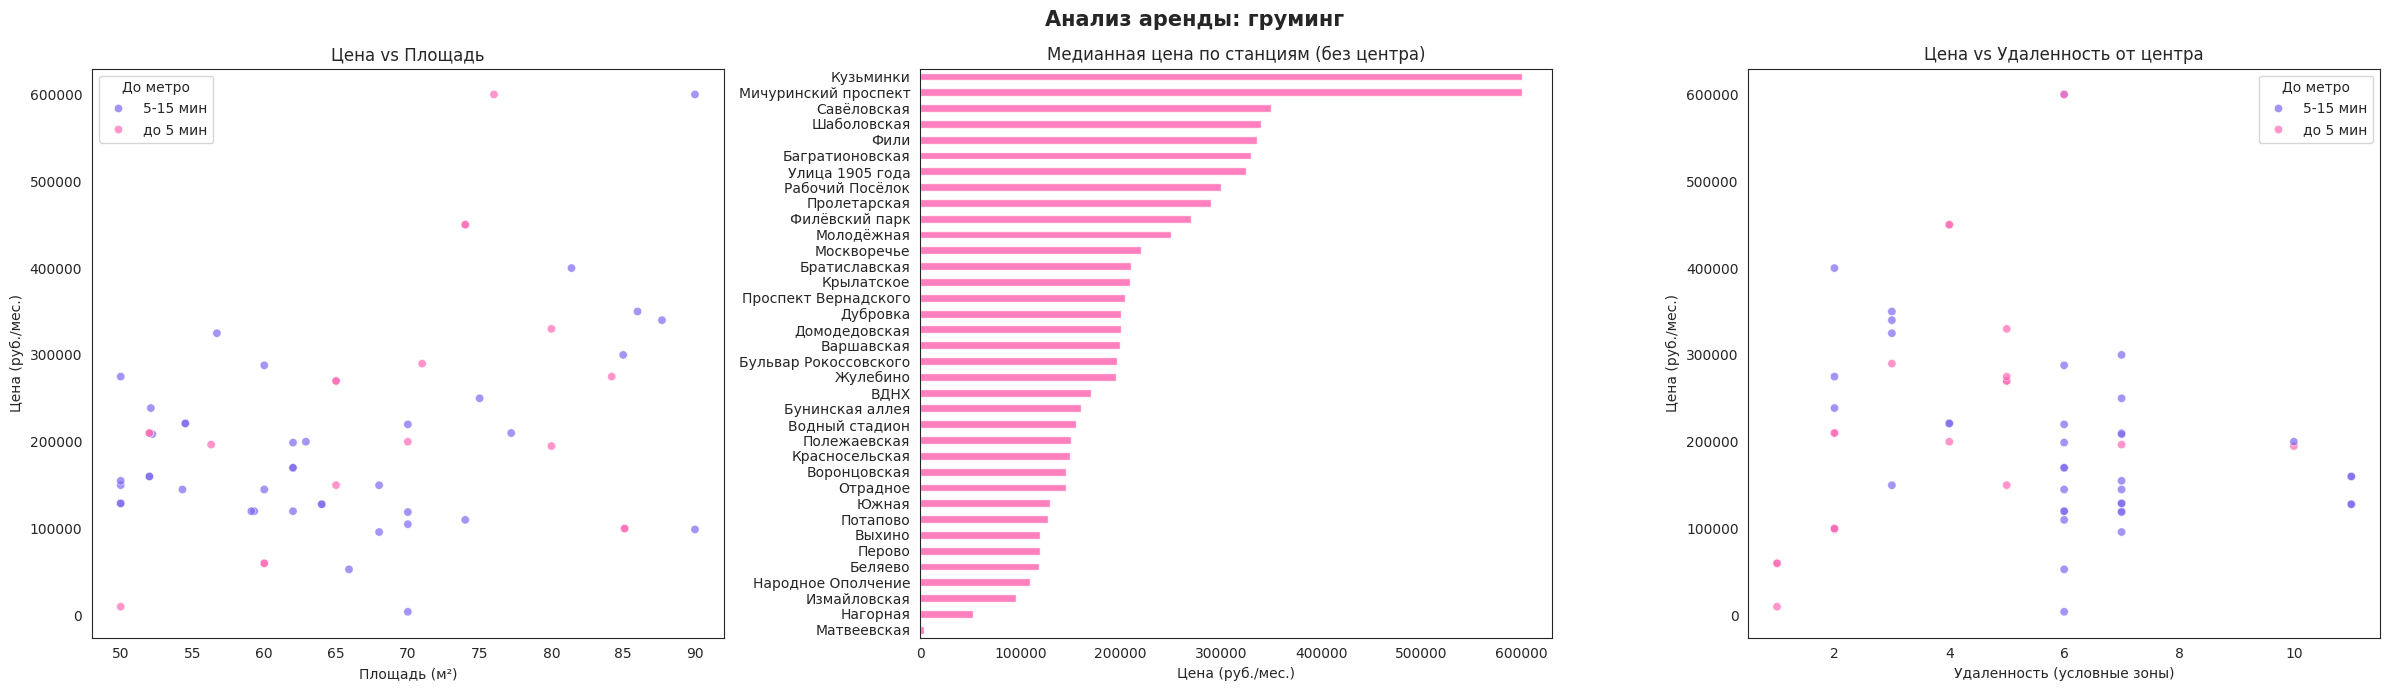

In [52]:
url = 'https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam/magazin-ASgBAgICAkSwCNRWnsMNiNk5?context=H4sIAAAAAAAA_wFtAJL_YTozOntzOjg6ImZyb21QYWdlIjtzOjEyOiJyZWNlbnRTZWFyY2giO3M6OToiZnJvbV9wYWdlIjtzOjEyOiJyZWNlbnRTZWFyY2giO3M6MToieSI7czoxNjoiMDhrZ3JwQ0lSQlNGeWRZWiI7faPhdQ9tAAAA&f=ASgBAgICA0SwCNRW9BKk2gGeww2I2Tk&p=4'
pp = AvitoParser(url, 'груминг')
pp.make_everything(15, 3, 50, 90)